In [1]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape: (2240, 29)

Column Names:
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income      

In [5]:
missing = df.isnull().sum()

missing_report = pd.DataFrame({
    'Column': missing.index,
    'Missing Values': missing.values
})

missing_report

,Column,Missing Values
0,ID,0
1,Year_Birth,0
2,Education,0
3,Marital_Status,0
4,Income,24
5,Kidhome,0
6,Teenhome,0
7,Dt_Customer,0
8,Recency,0
9,MntWines,0


In [6]:
df['Income'] = df['Income'].fillna(
    df['Income'].median()
)

In [7]:
duplicates = df.duplicated().sum()

print("Duplicates Found:", duplicates)

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicates Found: 0
New Shape: (2240, 29)


In [8]:
current_year = 2025

df['Age'] = current_year - df['Year_Birth']

df[['Year_Birth','Age']].head()

,Year_Birth,Age
0,1957,68
1,1954,71
2,1965,60
3,1984,41
4,1981,44


In [9]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

df[['Total_Spending']].head()

,Total_Spending
0,1617
1,27
2,776
3,53
4,422


In [10]:
summary = df.describe()

summary

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,56.194196,605.798214
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,602.249288
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,29.000000,5.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,48.000000,68.750000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,55.000000,396.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,66.000000,1045.500000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,132.000000,2525.000000


In [11]:
print("Total Customers:", len(df))

print("Average Income:",
      round(df['Income'].mean(),2))

print("Average Age:",
      round(df['Age'].mean(),2))

Total Customers: 2240
Average Income: 52237.98
Average Age: 56.19


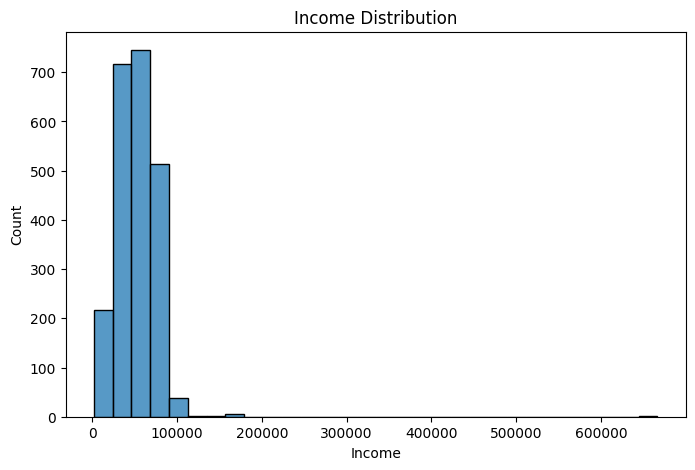

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Income'],
    bins=30
)

plt.title("Income Distribution")

plt.show()

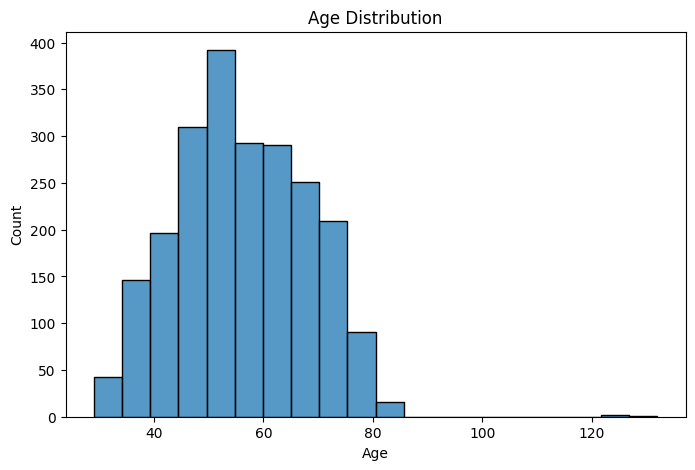

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20
)

plt.title("Age Distribution")

plt.show()

In [14]:
top_customers = df.sort_values(
    by='Total_Spending',
    ascending=False
)

top_customers[
    ['ID','Income','Total_Spending']
].head(10)

,ID,Income,Total_Spending
1572,5350,90638.0,2525
1179,5735,90638.0,2525
1492,1763,87679.0,2524
987,4580,75759.0,2486
1052,4475,69098.0,2440
1601,5453,90226.0,2352
1458,10133,93790.0,2349
1288,9010,83151.0,2346
1301,6024,94384.0,2302
943,5386,94384.0,2302


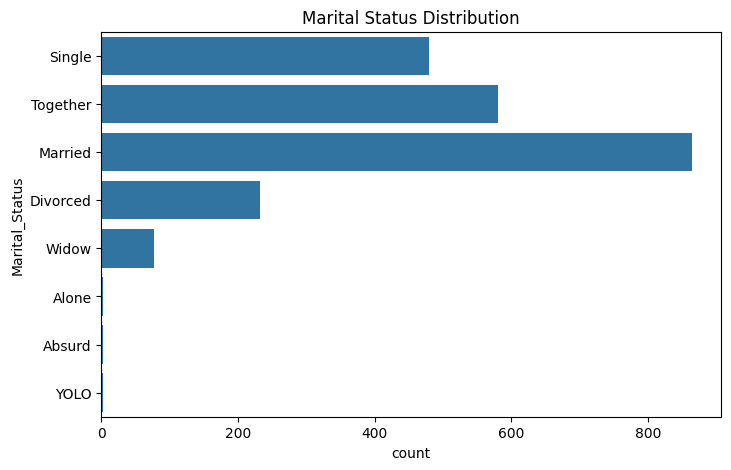

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='Marital_Status',
    data=df
)

plt.title("Marital Status Distribution")

plt.show()

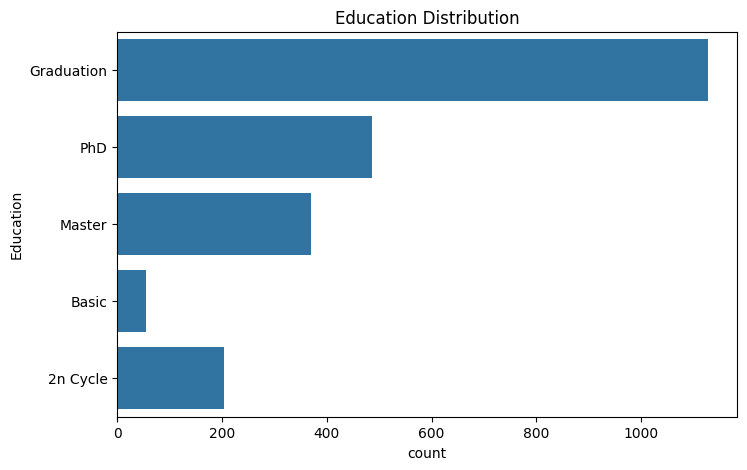

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='Education',
    data=df
)

plt.title("Education Distribution")

plt.show()

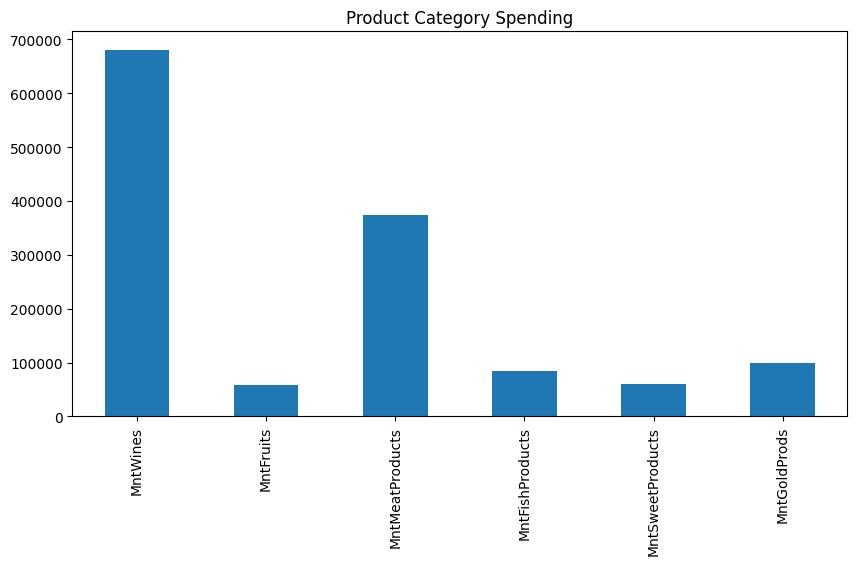

In [17]:
products = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

spending = df[products].sum()

spending.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Product Category Spending")

plt.show()

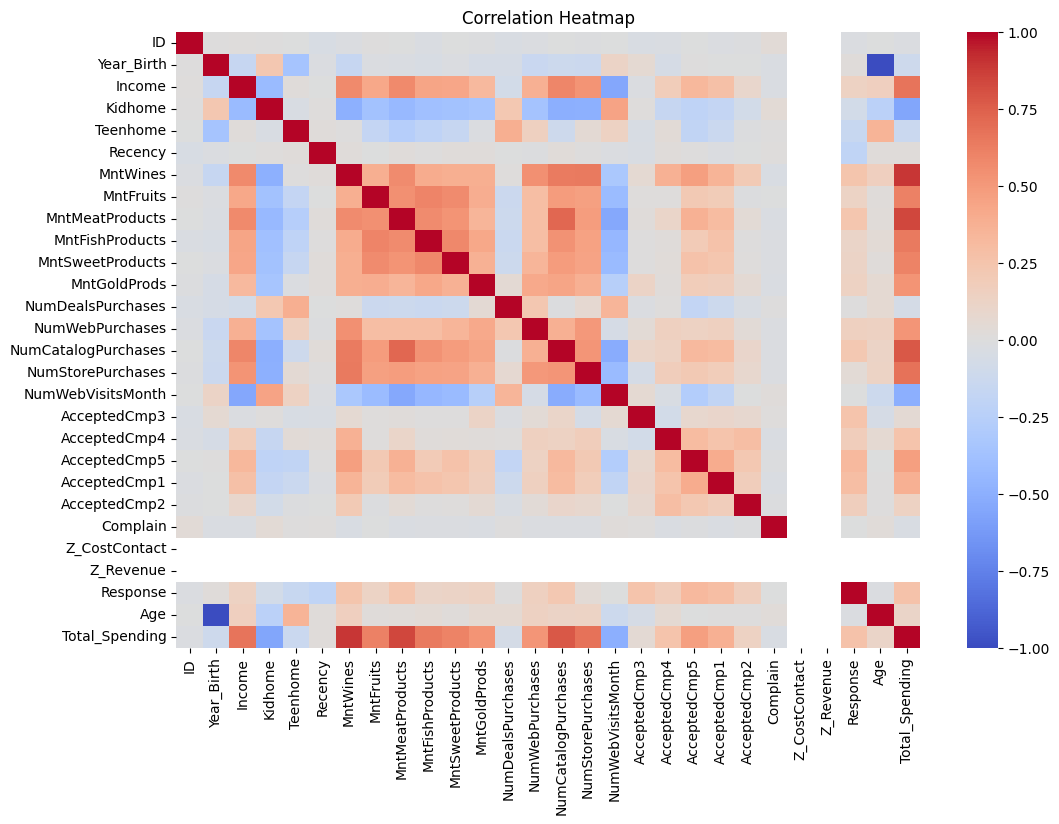

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
print("="*50)

print("AUTOMATED REPORT")

print("="*50)

print("Total Customers:",
      len(df))

print("Average Income:",
      round(df['Income'].mean(),2))

print("Average Spending:",
      round(df['Total_Spending'].mean(),2))

print("Highest Income:",
      round(df['Income'].max(),2))

print("Highest Spending:",
      round(df['Total_Spending'].max(),2))

AUTOMATED REPORT
Total Customers: 2240
Average Income: 52237.98
Average Spending: 605.8
Highest Income: 666666.0
Highest Spending: 2525


In [20]:
df.to_csv(
    "cleaned_customer_data.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [21]:
with pd.ExcelWriter(
    "Customer_Report.xlsx"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Cleaned_Data",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Summary_Report"
    )

print("Excel report generated.")

Excel report generated.


In [22]:
df['Customer_Segment'] = pd.cut(
    df['Total_Spending'],
    bins=[0,500,1500,3000],
    labels=['Low Spender',
            'Medium Spender',
            'High Spender']
)

df[['Total_Spending',
    'Customer_Segment']].head()

,Total_Spending,Customer_Segment
0,1617,High Spender
1,27,Low Spender
2,776,Medium Spender
3,53,Low Spender
4,422,Low Spender


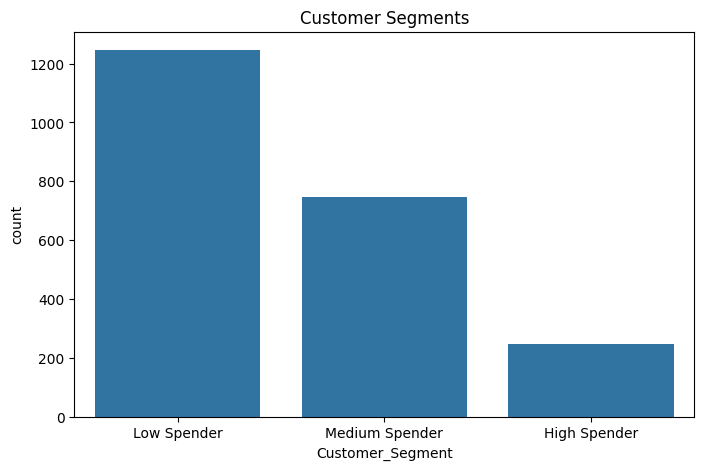

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Customer_Segment',
    data=df
)

plt.title("Customer Segments")
plt.show()

In [24]:
top_income = df.sort_values(
    by='Income',
    ascending=False
).head(10)

top_income[['ID',
            'Income',
            'Age']]

,ID,Income,Age
2233,9432,666666.0,48
617,1503,162397.0,49
687,1501,160803.0,43
1300,5336,157733.0,54
164,8475,157243.0,52
1653,4931,157146.0,48
2132,11181,156924.0,76
655,5555,153924.0,50
1898,4619,113734.0,80
646,4611,105471.0,55


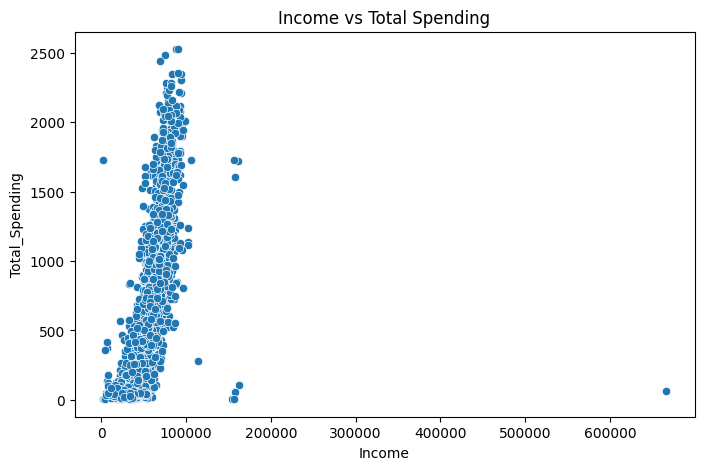

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending'
)

plt.title("Income vs Total Spending")

plt.show()

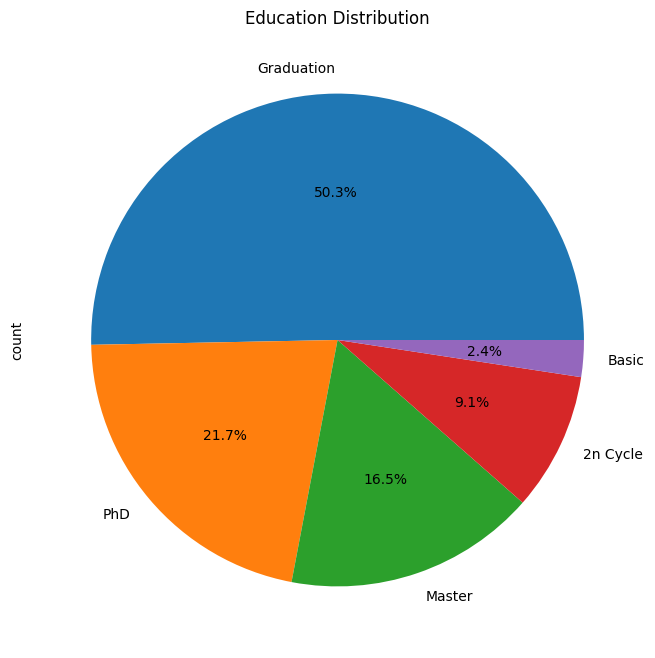

In [26]:
education_count = (
    df['Education']
    .value_counts()
)

education_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title("Education Distribution")

plt.show()

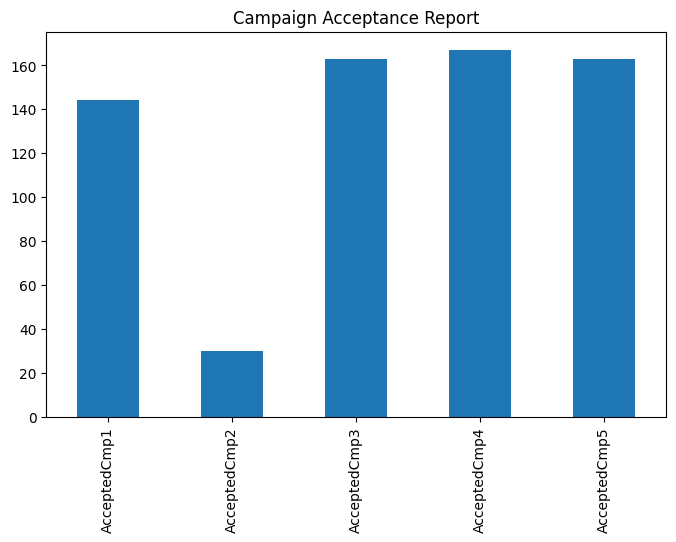

In [27]:
campaign_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]

campaign_report = (
    df[campaign_cols]
    .sum()
)

campaign_report.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Campaign Acceptance Report")

plt.show()

In [28]:
customer_summary = pd.DataFrame({
    'Metric':[
        'Total Customers',
        'Average Income',
        'Average Age',
        'Average Spending'
    ],

    'Value':[
        len(df),
        round(df['Income'].mean(),2),
        round(df['Age'].mean(),2),
        round(df['Total_Spending'].mean(),2)
    ]
})

customer_summary

,Metric,Value
0,Total Customers,2240.00
1,Average Income,52237.98
2,Average Age,56.19
3,Average Spending,605.80


In [29]:
customer_summary.to_csv(
    "Automated_Summary_Report.csv",
    index=False
)

print("Summary Report Saved Successfully")

Summary Report Saved Successfully
